## **Start**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from helper_functions import protocol_impure as im
from strawberryfields.ops import *
from importlib import reload
def reload_protocols():
    reload(im)

## Displaced Squeezed Thermal States (**DSTS**) - ***Produce*** data

In [12]:
mus_grid = np.linspace(0, 1, 201)
beta_grid = np.linspace(0, 1, 201)

In [ ]:
reload_protocols()

N = 2

num_samples = int(1e9)
sigmas = [0.0, 0.1, 0.2]
for sigma in sigmas:

    print(f"\n σ = {sigma}")
    
    # Compute error probabilities
    perr_dsts = im.perr_dsts(N, mus_grid, beta_grid, sigma, num_samples)
    
    #save data
    np.savez(f"data/DSTS/perr_dsts_N{N}_b{len(beta_grid)}_mu{len(mus_grid)}_S{num_samples}_sigma{sigma}.npz", N=N, beta_grid = beta_grid, mus_grid = mus_grid, perr=perr_dsts, sigma = sigma)



 σ = 0.0
Progress: 201/201
 σ = 0.1
Progress: 201/201
 σ = 0.2
Progress: 201/201

## Displaced Thermal States (**DTS**) - ***Produce*** data

In [ ]:
reload_protocols()

N = 2
#mus_grid = np.linspace(0, 1, 201)
num_samples = int(1e9)
sigmas = [0.0, 0.1, 0.2]
for sigma in sigmas:

    print(f"\n σ = {sigma}")
    
    # Compute error probabilities
    perr_dts = im.perr_dts(N, mus_grid, sigma, num_samples)
    #save data
    np.savez(f"data/DTS/perr_dts_N{N}_mu{len(mus_grid)}_S{num_samples}_sigma{sigma}.npz", N=N, mus_grid = mus_grid, perr=perr_dts, sigma = sigma)



 σ = 0.0
Progress: 201/201
 σ = 0.1
Progress: 201/201
 σ = 0.2
Progress: 201/201

## **Plots** - Homodyne Error Probability

In [3]:
colors_1 = ["#e56ee5",  "#2ca02c",  "#ff7f0e",  "#9467bd",  "#17becf",  "#e377c2",  "#8c564b",  "#bcbd22",  "#7f7f7f",  "#5af74b"]*3
colors_2 = ["#AD0B90",  "#084108",  "#773b05",  "#460880",  "#0c6f7c",  "#5c0642",  "#941c04",  "#8b8b06",  "#212121",  "#092a06",  "#092a06"]*3

In [48]:
reload_protocols()
sigmas = [0.0]
im.plot_homodyne_perr(sigmas, colors_1, colors_2, dsts = 'all', dts = 'all')

## **Plots** - Beta threshold / optimal 

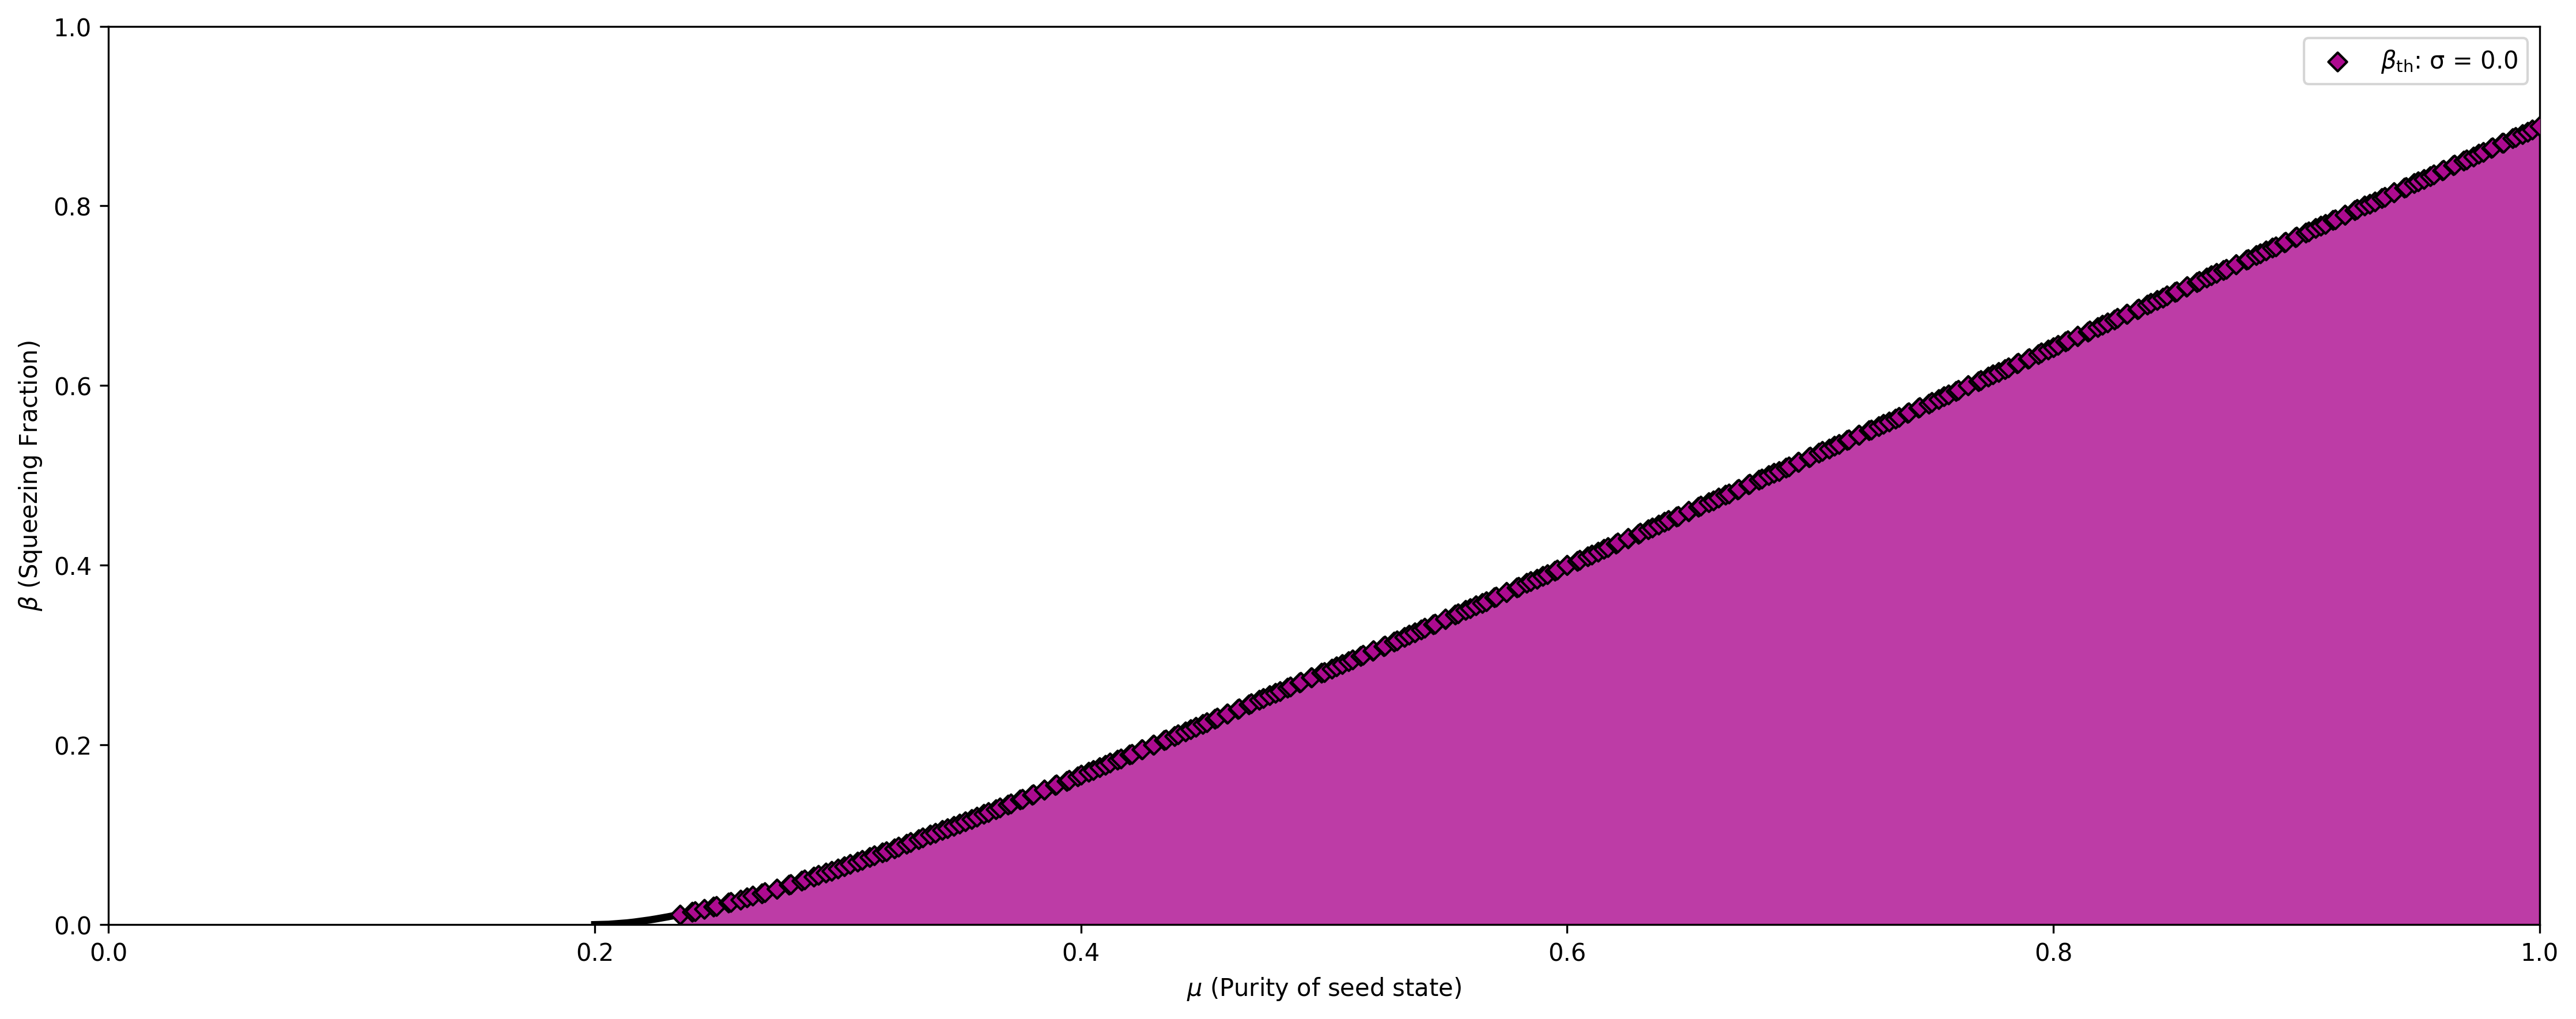

In [49]:
reload_protocols()
sigmas = [0.0]
beta_opt = im.optimal_squeezing(sigmas, colors_1, colors_2, opt = False, th = True)

In [ ]:
reload_protocols()
N_vals = [2, 4, 6, 8]
colors = ['orange', 'magenta', 'cyan', 'blue']

sigma_thresholds = np.zeros((len(N_vals), len(mus_grid)))

for i, N in enumerate(N_vals):
    sigma_thresholds[i] = im.sigma_threshold_theory(N, mus_grid)

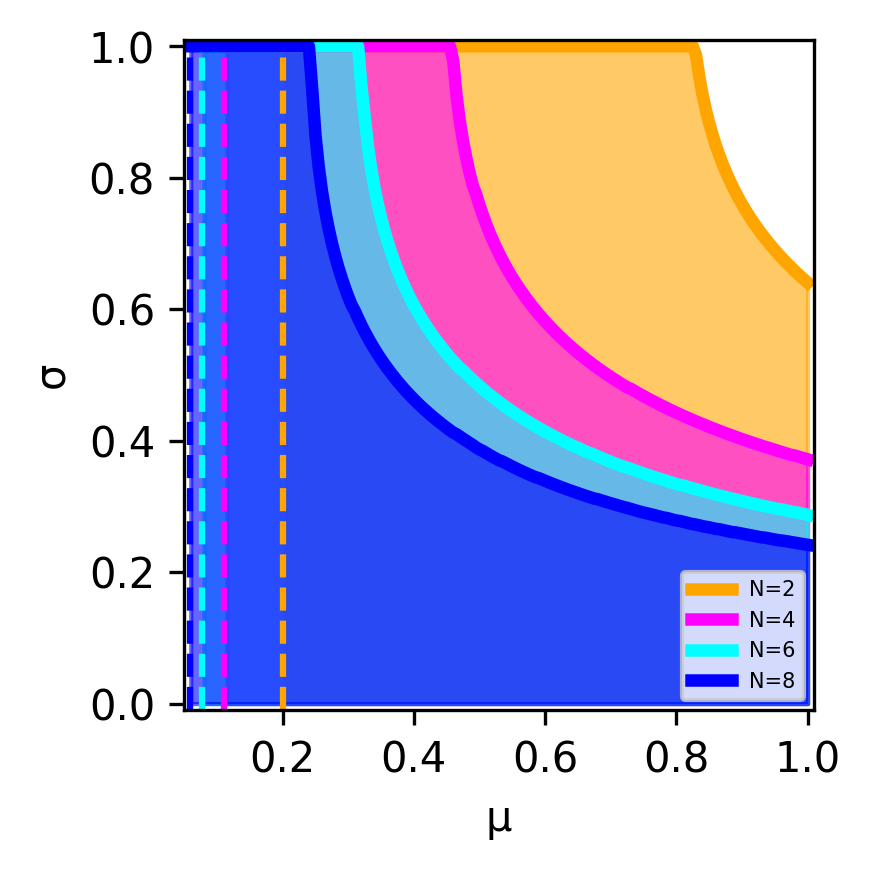

In [59]:
plt.figure(figsize=(3, 3), dpi=300)

for i, N in enumerate(N_vals):
    plt.plot(mus_grid, sigma_thresholds[i], color=colors[i], linewidth=3, label=f'N={N}')
    plt.fill_between(mus_grid, sigma_thresholds[i], 0, color=colors[i], alpha=0.6)
    plt.axvline(x=1/(1+2*N), linestyle='--', color=colors[i])

plt.ylim(-0.01, 1.01)
plt.xlim(0.05, 1.01)
plt.xlabel('μ')
plt.ylabel('σ')
plt.legend(fontsize=5)
plt.tight_layout()
plt.show()


## kyproula test cell

In [ ]:
from numpy.polynomial.hermite import hermgauss

N = 2
sigma = 0.0
mu = 0.70

gauss = hermgauss(100)

beta_max = mu + (mu - 1)/(2*N)
beta = np.linspace(0, beta_max, 1000)

point_dts = im.theory_point_dts(N, mu, sigma, gauss)

F = [im.theory_point_dsts(N, b, mu, sigma, gauss) - point_dts
     for b in beta]

plt.figure(figsize=(6,4))
plt.plot(beta, F)
plt.axhline(0, color='k', ls='--')
plt.axvline(beta[np.argmin(F)], color='r', ls=':')
plt.xlabel(r'$\beta$')
plt.ylabel(r'$F(\beta)$')
plt.title(fr'$\mu={mu}$')
plt.grid(True)
plt.show()

print("min(F) =", np.min(F))
print("F(beta_max) =", F[-1])